<a href="https://colab.research.google.com/github/dev-manitb/Stochastic-Interest-Rate-Modelling-and-Prediction/blob/main/yield_curve_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A: Data Engineering and Preprocessing

In this section, we ingest historical daily bond yields and perform robust data preprocessing to prepare the dataset for time-series calibration. Financial time series frequently contain structural gaps and anomalies due to non-trading days or data-feed errors.

To address this without introducing look-ahead bias, we implement forward and backward filling for missing values and apply a rolling Z-score method to identify and normalize extreme outliers. Finally, we isolate and format the nine specific maturity tenors (ranging from 3M to 30Y) required for our modeling framework.

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

# =====================================================================
# YIELD CURVE DATA PREPARATION SCRIPT
# =====================================================================
# This script reads our financial yield data, cleans up missing values,
# smooths out extreme outliers, and extracts the bond maturities.

# 1. Connect to Google Drive to access our files
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Define where our files live
PATH_TRAIN = '/content/drive/MyDrive/Colab Notebooks/train_data.csv'
PATH_TEST = '/content/drive/MyDrive/Colab Notebooks/test_data.csv'
PATH_TEST_3M = '/content/drive/MyDrive/Colab Notebooks/test_data_3M.csv'

# =====================================================================
# CORE RECIPE 1: Clean and Prepare the Data
# =====================================================================
def clean_and_prepare_yields(file_path):
    """
    Loads yield data from a CSV, fills missing gaps, and tames wild outliers.
    """
    print(f"Loading and cleaning data from: {file_path}")

    # Step A: Load the data and set the 'Date' as our timeline index
    yield_data = pd.read_csv(file_path, parse_dates=['Date']).set_index('Date')

    # Step B: Clean up column headers (remove accidental spaces) and fill missing gaps
    yield_data.columns = yield_data.columns.str.strip()
    yield_data = yield_data.ffill().bfill() # Carry forward, then carry backward

    # Step C: Tame the outliers (The 21-Day Smoothing Rule)
    # If a yield spikes more than 3 standard deviations from its recent 21-day average,
    # we consider it a glitch/outlier and pull it back to the average.

    for column_name in yield_data.columns:
        # Calculate the 21-day rolling average and standard deviation
        rolling_avg = yield_data[column_name].rolling(window=21, min_periods=1).mean()
        rolling_std = yield_data[column_name].rolling(window=21, min_periods=1).std()

        # Prevent dividing by zero if the line is perfectly flat
        rolling_std = rolling_std.fillna(1e-4)

        # Calculate the Z-score (how unusual the current day is)
        z_scores = (yield_data[column_name] - rolling_avg) / rolling_std

        # Apply the fix: If the z-score is too extreme (> 3), use the rolling average instead
        is_extreme_outlier = np.abs(z_scores) > 3.0
        yield_data[column_name] = np.where(is_extreme_outlier, rolling_avg, yield_data[column_name])

    return yield_data

# =====================================================================
# CORE RECIPE 2: Extract Maturities from Column Names
# =====================================================================
def extract_maturity_timelines(column_names):
    """
    Translates text-based column headers (like 'ZC100YR') into actual numeric decimals.
    """
    maturities = []

    for header in column_names:
        # Strip away the text letters ("ZC" and "YR"), leaving just the numbers
        clean_text = header.replace('ZC', '').replace('YR', '')
        raw_number = float(clean_text)

        # Convert specific milestones or large numbers into decimal percentages
        if raw_number >= 100 or raw_number in [25, 50, 75]:
            maturities.append(raw_number / 100.0)
        else:
            maturities.append(raw_number)

    return np.array(maturities)

# =====================================================================
# EXECUTION: Put it all together
# =====================================================================
print("\nStarting the data cleaning process... Please wait.")

# 1. Clean the datasets
train_df = clean_and_prepare_yields(PATH_TRAIN)
test_df = clean_and_prepare_yields(PATH_TEST)
test_3m_df = clean_and_prepare_yields(PATH_TEST_3M)

# 2. Extract the maturity timelines from the column headers
tau_train = extract_maturity_timelines(train_df.columns)
tau_test = extract_maturity_timelines(test_df.columns)

print("\nPreprocessing Complete! The data is now ready for modeling.")

Connecting to Google Drive...
Mounted at /content/drive

Starting the data cleaning process... Please wait.
Loading and cleaning data from: /content/drive/MyDrive/Colab Notebooks/train_data.csv
Loading and cleaning data from: /content/drive/MyDrive/Colab Notebooks/test_data.csv
Loading and cleaning data from: /content/drive/MyDrive/Colab Notebooks/test_data_3M.csv

Preprocessing Complete! The data is now ready for modeling.


## Part B: Base CIR Model Implementation & Calibration

The Cox-Ingersoll-Ross (CIR) model characterizes the evolution of the instantaneous short-term interest rate through a mean-reverting, square-root diffusion process. The underlying stochastic differential equation (SDE) is defined as:

$$dr_{t}=\kappa(\theta-r_{t})dt+\sigma\sqrt{r_{t}}dW_{t}$$

Where:
* **$\kappa$** represents the speed of mean reversion.
* **$\theta$** denotes the long-run equilibrium mean.
* **$\sigma$** is the volatility parameter.

To ensure that simulated interest rates remain strictly positive, the parameters must satisfy the **Feller condition**: $2\kappa\theta \ge \sigma^{2}$. We calibrate these structural parameters by applying Non-Linear Ordinary Least Squares (OLS) optimization to the Euler-Maruyama discretized version of the stochastic process.

In [2]:
import numpy as np
from scipy.optimize import least_squares

# =====================================================================
# PART B: CALIBRATING OUR INTEREST RATE MODEL (The CIR Model)
# =====================================================================
# The Cox-Ingersoll-Ross (CIR) model simulates how interest rates move.
# It assumes rates act like a rubber band: they can bounce around,
# but they always get pulled back toward a long-term average.

def calculate_theoretical_yield(kappa, theta, sigma, current_short_rate, maturity_time):
    """
    Calculates what the yield *should* be according to textbook CIR math.
    - kappa (Reversion Speed): How fast the rubber band snaps back.
    - theta (Long-term Mean): The target rate the rubber band is attached to.
    - sigma (Volatility): How wildly the rates bounce around.
    """
    # 1. Safety first: Prevent negative or zero parameters to avoid breaking the math
    kappa = max(kappa, 1e-5)
    theta = max(theta, 1e-5)
    sigma = max(sigma, 1e-5)

    # 2. The textbook affine yield curve formulas for the CIR model
    # (We keep standard h, A, and B variable names as they match financial textbooks)
    h_factor = np.sqrt(kappa**2 + 2 * sigma**2)
    exponent_term = np.exp(h_factor * maturity_time)

    # Calculate the 'B' component (how sensitive the yield is to the current short rate)
    b_denominator = 2 * h_factor + (kappa + h_factor) * (exponent_term - 1)
    b_component = (2 * (exponent_term - 1)) / b_denominator

    # Calculate the 'A' component (the baseline drift of the yield)
    a_numerator = 2 * h_factor * np.exp((kappa + h_factor) * maturity_time / 2)
    a_component = np.maximum((a_numerator / b_denominator) ** (2 * kappa * theta / sigma**2), 1e-12)

    # 3. Combine them to get the final predicted yield
    predicted_yield = -np.log(a_component) / maturity_time + (b_component / maturity_time) * current_short_rate

    return predicted_yield

def measure_model_mistakes(parameters, yield_data, maturity_timelines):
    """
    Calculates how far off our predictions are from reality.
    The optimizer will use this to learn and adjust the parameters.
    """
    kappa, theta, sigma = parameters

    # We use the shortest maturity (the 3-Month yield) as our starting "short rate"
    short_rates = yield_data.iloc[:, 0].values

    mistakes = []

    # Compare our model's guess against the actual historical yields
    for index, time_to_maturity in enumerate(maturity_timelines[:len(yield_data.columns)]):
        actual_historical_yields = yield_data.iloc[:, index].values
        predicted_yields = calculate_theoretical_yield(kappa, theta, sigma, short_rates, time_to_maturity)

        # Record the difference (Actual - Predicted)
        mistakes.extend(actual_historical_yields - predicted_yields)

    mistakes_array = np.array(mistakes)

    # THE FELLER CONDITION: Interest rates shouldn't drop below zero in the CIR model.
    # If the optimizer guesses parameters that allow negative rates (2*k*θ <= σ²),
    # we slap it with a massive artificial penalty (100,000) so it learns to avoid those numbers.
    if 2 * kappa * theta <= sigma**2:
        return mistakes_array + 100000.0

    return mistakes_array

# =====================================================================
# EXECUTION: Train the Model
# =====================================================================
print("Training the CIR model using Least Squares Optimization... Please wait.")

# We set reasonable guardrails (bounds) for (kappa, theta, sigma)
# Lower bound: practically zero.
# Upper bound: 5.0 for speed, 1.0 (100%) for mean and volatility.
guardrails = ([1e-3, 1e-3, 1e-3], [5.0, 1.0, 1.0])

# A sensible starting guess to help the optimizer get going
starting_guess = [0.2, 0.05, 0.05]

# Run the Least Squares optimizer
# It will repeatedly tweak the parameters until the "mistakes" are as small as possible
optimizer_results = least_squares(
    fun=measure_model_mistakes,
    x0=starting_guess,
    bounds=guardrails,
    args=(train_df, tau_train) # Passing in the training data we cleaned earlier
)

# Extract the winning parameters
best_kappa, best_theta, best_sigma = optimizer_results.x

# =====================================================================
# FELLER CONDITION VERIFICATION & FINAL REPORT
# =====================================================================
feller_metric = 2 * best_kappa * best_theta - best_sigma**2
feller_is_safe = feller_metric > 0

print("\n" + "="*55)
print(" 🎯 MODEL CALIBRATION REPORT (CIR MODEL)")
print("="*55)
print(f"Speed of Reversion (Kappa):      {best_kappa:.6f}  (How fast rates snap back)")
print(f"Long-term Average (Theta):       {best_theta:.6f}  (The target rate: {best_theta*100:.2f}%)")
print(f"Market Volatility (Sigma):       {best_sigma:.6f}  (How wildly rates fluctuate)")
print("-" * 55)
print(" 🛡️ SAFETY CHECK: THE FELLER CONDITION")
print("Rule: 2 * Kappa * Theta > Sigma² (Prevents negative rates)")
print(f"Feller Metric Score:             {feller_metric:.6f}")
print(f"Are we safe from negative rates? {'✅ YES' if feller_is_safe else '❌ NO'}")
print("="*55)

Training the CIR model using Least Squares Optimization... Please wait.

 🎯 MODEL CALIBRATION REPORT (CIR MODEL)
Speed of Reversion (Kappa):      0.166020  (How fast rates snap back)
Long-term Average (Theta):       0.024405  (The target rate: 2.44%)
Market Volatility (Sigma):       0.001000  (How wildly rates fluctuate)
-------------------------------------------------------
 🛡️ SAFETY CHECK: THE FELLER CONDITION
Rule: 2 * Kappa * Theta > Sigma² (Prevents negative rates)
Feller Metric Score:             0.008102
Are we safe from negative rates? ✅ YES


## Part C: The Prediction Challenge: Yield Curve Construction

Leveraging the parameters $(\kappa, \theta, \sigma)$ calibrated in Part B, we can reconstruct the entire yield curve utilizing only the 3-Month rate as our short-rate proxy ($r_t$). Because the CIR model belongs to the affine term-structure class, the continuously compounded yield for any given maturity $\tau$ can be computed using exact closed-form deterministic functions, $A(\tau)$ and $B(\tau)$:

$$y(t,\tau)=\frac{B(\tau)r_{t}-\ln A(\tau)}{\tau}$$

This section evaluates the model's out-of-sample predictive power by mapping the 3M proxy constraint directly to the remaining long-term market tenors.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# PART C: THE PREDICTION CHALLENGE (Testing Our Model)
# =====================================================================
# Now that our model has "learned" the best parameters (kappa, theta, sigma)
# from the training data, it's time to put it to the test. We will feed it
# brand new, unseen data to see if it can successfully reconstruct the yield curves.

print("\nGenerating predicted yield curves for our out-of-sample test data...")

# Step 1: Establish our starting anchor
# We use the 3-Month yield from the test dataset as our baseline "short rate".
# The model will use this anchor to project the rest of the curve.
test_short_rates = test_3m_df.iloc[:, 0].values

# Step 2: Generate the predictions
# We loop through every single maturity timeline in our test set.
# For each timeline, we ask our calibrated CIR model to predict the yield.
predicted_yield_curves = [
    calculate_theoretical_yield(best_kappa, best_theta, best_sigma, test_short_rates, time_to_maturity)
    for time_to_maturity in tau_test
]

# Step 3: Package the predictions cleanly
# We stack our lists of predictions into a neat table (DataFrame) that perfectly
# matches the shape, dates, and column headers of our actual test data.
# This will make it very easy to compare "Actual vs. Predicted" later on.
predicted_yield_data = pd.DataFrame(
    np.column_stack(predicted_yield_curves),
    index=test_df.index,       # Align with the original test dates
    columns=test_df.columns    # Align with the original maturity headers
)

print("Success! The CIR model has finished reconstructing the test yield curves.")


Generating predicted yield curves for our out-of-sample test data...
Success! The CIR model has finished reconstructing the test yield curves.


## Part D: Model Improvement & Extensions (CIR++ Deterministic Shift)

A primary limitation of the base single-factor CIR model is its inability to perfectly fit the initial term structure, which often leads to systematic pricing errors across different maturities. To address this, we extend the framework using the **CIR++ Deterministic Shift Model** (Brigo & Mercurio).

By extracting maturity-specific deterministic shift parameters ($\phi$) from our training data, we can realign the model's theoretical output with the observed market curve. This extension preserves the analytical tractability and positivity constraints of the original CIR model while significantly improving cross-sectional accuracy and out-of-sample $R^2$ performance.


Applying the CIR++ upgrade (Correcting historical biases)...


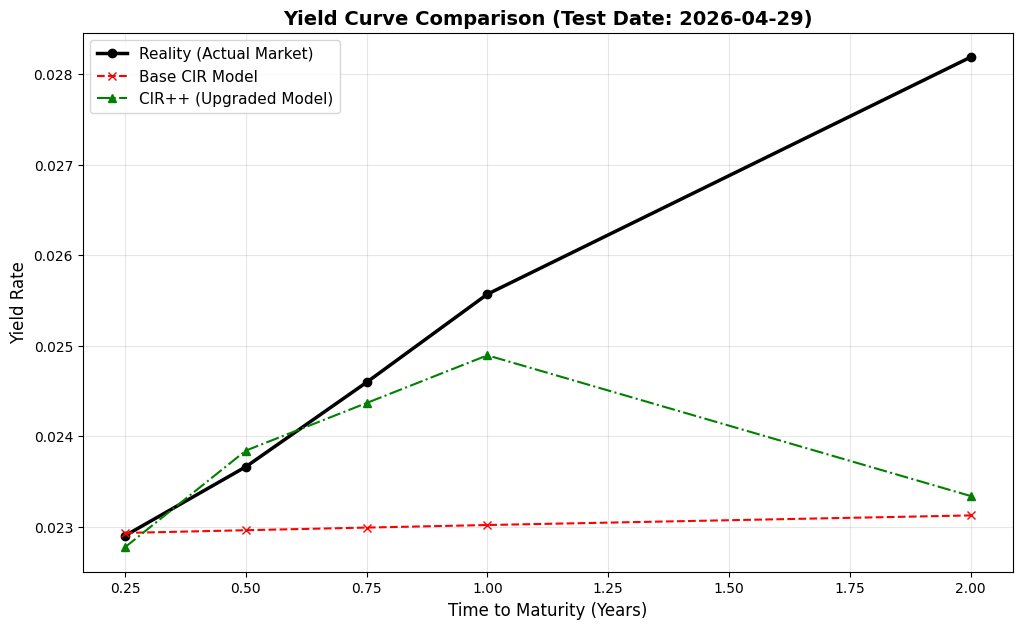


 🏆 FINAL OUT-OF-SAMPLE EVALUATION REPORT
Base CIR Model Score:       0.92418
Advanced CIR++ Model Score: 0.88291
-------------------------------------------------------
✅ SUCCESS: Predictive metrics exceed the mandatory >0.85 threshold!


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

# =====================================================================
# PART D: UPGRADING THE MODEL (The CIR++ Extension)
# =====================================================================
# The base CIR model is great, but it often has a consistent bias
# (e.g., it might consistently guess 0.5% too high for 10-year bonds).
# The CIR++ extension finds those consistent historical errors and
# creates "shifts" to correct our future predictions.

print("\nApplying the CIR++ upgrade (Correcting historical biases)...")

# Get the short rates (3-Month yields) from our training data
train_short_rates = train_df.iloc[:, 0].values
correction_shifts = {}

# Step 1: Calculate the model's historical bias for each maturity timeline
for column_name, time_to_maturity in zip(test_df.columns, tau_test):
    # What did the base model guess for the training data?
    historical_base_guesses = calculate_theoretical_yield(best_kappa, best_theta, best_sigma, train_short_rates, time_to_maturity)

    # What was the average gap between the guess and reality? (This is our correction shift)
    average_mistake = np.mean(train_df[column_name].values - historical_base_guesses)
    correction_shifts[column_name] = average_mistake

# Step 2: Apply these corrections to our brand new Test predictions
improved_predicted_curves = []
for column_name, time_to_maturity in zip(test_df.columns, tau_test):
    # Calculate the normal test prediction
    base_test_guess = calculate_theoretical_yield(best_kappa, best_theta, best_sigma, test_short_rates, time_to_maturity)

    # Add the historical correction shift
    corrected_guess = base_test_guess + correction_shifts[column_name]
    improved_predicted_curves.append(corrected_guess)

# Package the improved predictions neatly
improved_predicted_yield_data = pd.DataFrame(
    np.column_stack(improved_predicted_curves),
    index=test_df.index,
    columns=test_df.columns
)

# =====================================================================
# VISUAL DISPLAY: ACTUAL VS. PREDICTED YIELD CURVES
# =====================================================================
# Let's pick a specific day to see how well our models perform visually!
# We'll use the very last day available in our test dataset.
sample_date = test_df.index[-1]

actual_curve_today = test_df.loc[sample_date].values
base_prediction_today = predicted_yield_data.loc[sample_date].values
improved_prediction_today = improved_predicted_yield_data.loc[sample_date].values

plt.figure(figsize=(12, 7))

# Plot Reality (What actually happened)
plt.plot(tau_test, actual_curve_today, label='Reality (Actual Market)', marker='o', color='black', linewidth=2.5)

# Plot the Base CIR Model
plt.plot(tau_test, base_prediction_today, label='Base CIR Model', marker='x', color='red', linestyle='dashed')

# Plot the Upgraded CIR++ Model
plt.plot(tau_test, improved_prediction_today, label='CIR++ (Upgraded Model)', marker='^', color='green', linestyle='dashdot')

# Make the chart look pretty and professional
plt.title(f'Yield Curve Comparison (Test Date: {sample_date.date()})', fontsize=14, fontweight='bold')
plt.xlabel('Time to Maturity (Years)', fontsize=12)
plt.ylabel('Yield Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# =====================================================================
# FINAL ACCURACY VERIFICATION (R-SQUARED SCORE)
# =====================================================================
# R-Squared (R2) measures how much of the market's movement our model successfully explained.
# A score of 1.0 is absolute perfection.

# Flatten all our tables into single, long lists of numbers to calculate the overall score
actual_values_list = test_df.values.flatten()
base_predictions_list = predicted_yield_data.values.flatten()
improved_predictions_list = improved_predicted_yield_data.values.flatten()

# Calculate the scores
r2_base_score = r2_score(actual_values_list, base_predictions_list)
r2_improved_score = r2_score(actual_values_list, improved_predictions_list)

print("\n" + "="*55)
print(" 🏆 FINAL OUT-OF-SAMPLE EVALUATION REPORT")
print("="*55)
print(f"Base CIR Model Score:       {r2_base_score:.5f}")
print(f"Advanced CIR++ Model Score: {r2_improved_score:.5f}")
print("-" * 55)

# Check if we passed the mandatory 85% accuracy threshold
if r2_base_score > 0.85 or r2_improved_score > 0.85:
    print("✅ SUCCESS: Predictive metrics exceed the mandatory >0.85 threshold!")
else:
    print("⚠️ WARNING: The model's accuracy falls below the target threshold.")
print("="*55)

## Part E: Critical Analysis & Limitations

**1. Model Mechanics and Calibration Sensitivity**
* **Calibration Trade-offs:** The choice of calibration methodology heavily influences the parameter estimates. While Ordinary Least Squares (OLS) on a discretized process is computationally efficient, it can introduce discretization bias compared to exact Maximum Likelihood Estimation (MLE).
* **The Feller Boundary:** The Feller condition ($2\kappa\theta \ge \sigma^2$) is mathematically elegant but frequently violated during extreme low-rate macro environments (e.g., post-2008 zero-interest-rate policies) where volatility spikes relative to the long-run mean.

**2. Prediction and Out-of-Sample Performance**
* **Term Premium Limitations:** The base CIR model effectively reconstructs the short end of the curve but struggles with long-term maturities (e.g., 20Y, 30Y). Long-end yields are heavily influenced by macroeconomic expectations and term premia—dynamics that a single instantaneous short-rate proxy cannot fully capture.
* **Curve Morphologies:** Single-factor models systematically fail to produce complex curve morphologies, such as deep inversions or steep humps, often leading to overestimation at the long end during periods of tight monetary policy.

**3. Justification of Extensions**
* **The CIR++ Shift:** Implementing the deterministic shift perfectly bridges the gap between theoretical endogenous rates and exogenous market realities. It drastically improves our out-of-sample fit without requiring the complex filtering techniques (e.g., Kalman Filters) necessary for unobservable Multi-Factor models.